Primero importaremos la base de datos que vamos a utilizar

In [2]:
import kagglehub
from pathlib import Path
dataset_path = Path(kagglehub.dataset_download("emmanuelfwerr/thyroid-disease-data"))

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
import pandas as pd
df = pd.read_csv(dataset_path / "thyroidDF.csv")

Ahora  con la opción df.head obtendremos las 5 primeras filas con sus respectivos valores y podremos ver los nombres de las columnas

In [ ]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


In [ ]:
#Comprobar cuantos valores tienen las columnas
df.count()

age                    9172
sex                    8865
on_thyroxine           9172
query_on_thyroxine     9172
on_antithyroid_meds    9172
sick                   9172
pregnant               9172
thyroid_surgery        9172
I131_treatment         9172
query_hypothyroid      9172
query_hyperthyroid     9172
lithium                9172
goitre                 9172
tumor                  9172
hypopituitary          9172
psych                  9172
TSH_measured           9172
TSH                    8330
T3_measured            9172
T3                     6568
TT4_measured           9172
TT4                    8730
T4U_measured           9172
T4U                    8363
FTI_measured           9172
FTI                    8370
TBG_measured           9172
TBG                     349
referral_source        9172
target                 9172
patient_id             9172
dtype: int64

In [ ]:
#Comprobar el tipo de datos de cada columna con pandas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   str    
 2   on_thyroxine         9172 non-null   str    
 3   query_on_thyroxine   9172 non-null   str    
 4   on_antithyroid_meds  9172 non-null   str    
 5   sick                 9172 non-null   str    
 6   pregnant             9172 non-null   str    
 7   thyroid_surgery      9172 non-null   str    
 8   I131_treatment       9172 non-null   str    
 9   query_hypothyroid    9172 non-null   str    
 10  query_hyperthyroid   9172 non-null   str    
 11  lithium              9172 non-null   str    
 12  goitre               9172 non-null   str    
 13  tumor                9172 non-null   str    
 14  hypopituitary        9172 non-null   str    
 15  psych                9172 non-null   str    
 16 

In [ ]:
import numpy as np

# Preserve original labels for traceability and idempotency
if "target_raw" not in df.columns:
    df["target_raw"] = df["target"]
df["target"] = np.select(
    [
        df["target_raw"].str.contains("[A-D]", na=False), 
        df["target_raw"].str.contains("[E-H]", na=False)
    ],
    ["hyperthyroid", "hypothyroid"],
    default="negative"
)

print(f"Dataset shape: {df.shape[0]} samples, {df.shape[1]} features")
print("\nTarget distribution:")
display(pd.DataFrame({
    'Count': df['target'].value_counts(),
    'Percentage (%)': (df['target'].value_counts(normalize=True) * 100).round(1)
}))

Dataset shape: 9172 samples, 32 features

Target distribution:


,Count,Percentage (%)
target,,
negative,8264,90.1
hypothyroid,667,7.3
hyperthyroid,241,2.6


Para este caso no nos hacen falta las columnas SVI, SVHC, STMW, SVHD... Estas representan de donde vienen los pacientes, podríamos suponer que si vienen de STMW tendrían el 50% de probabilidad de tener tiroides, ya que este es un centro específico de tiroides pero en este caso vamos a omitir estos datos. En el caso de querer podriamos usar un Logistic Regression o Tree Regression.


In [ ]:
df.drop(columns=['patient_id', 'referral_source'], inplace=True)

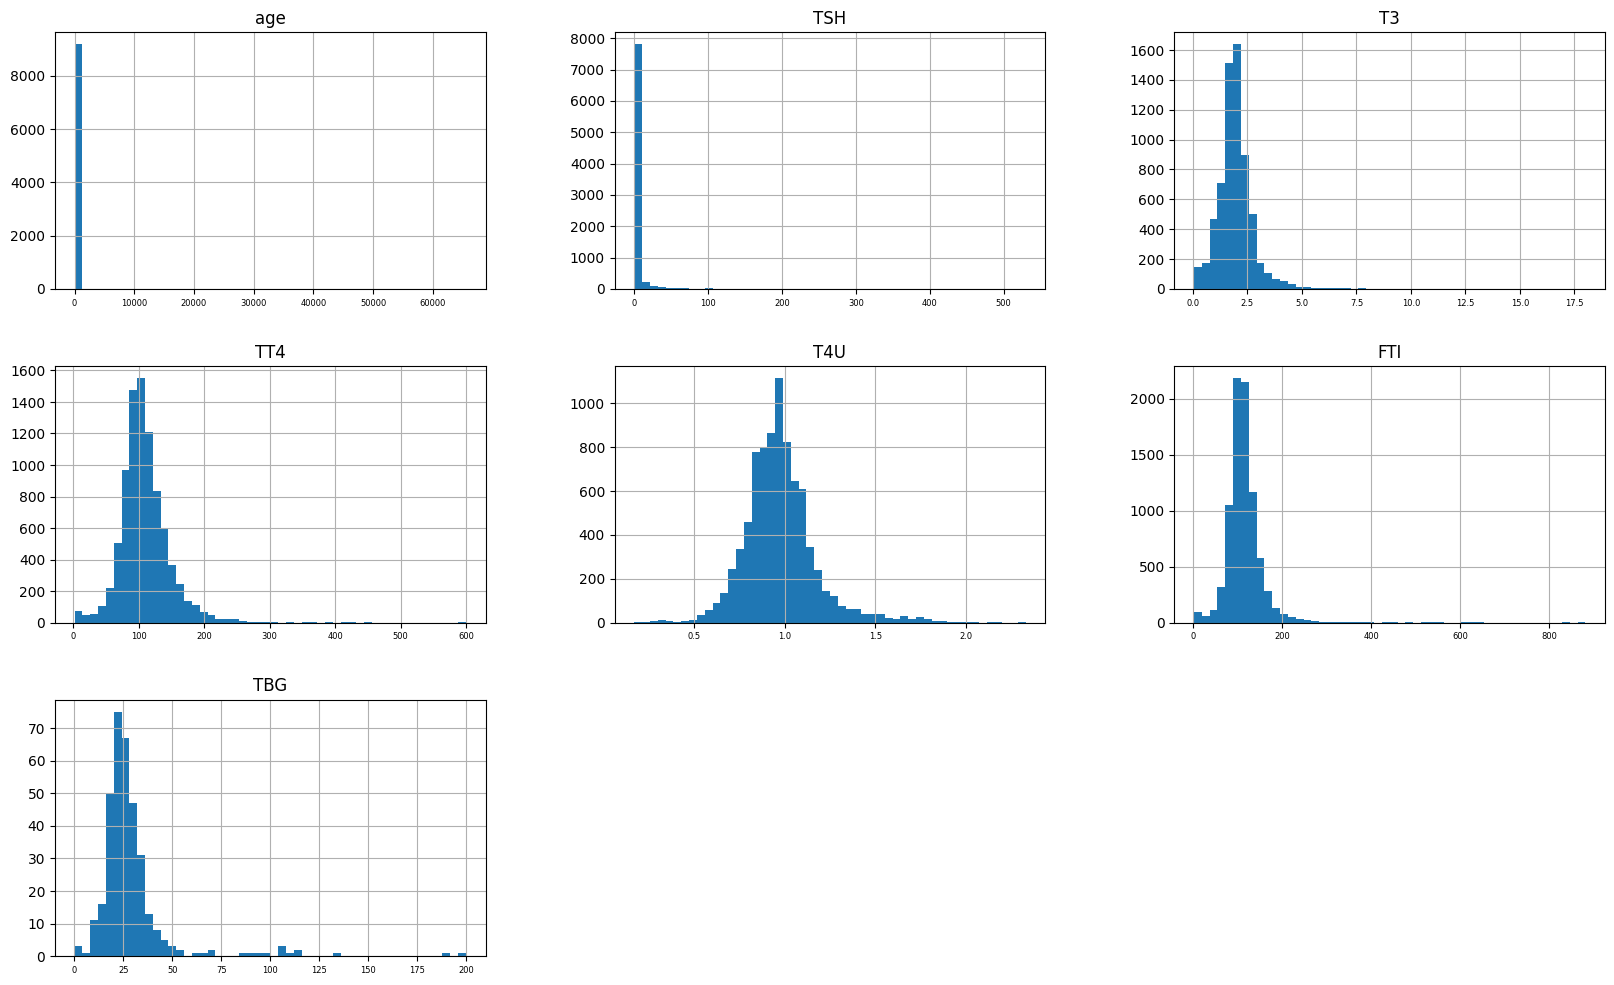

In [ ]:
import matplotlib.pyplot as plt
_ = df.hist(bins=50, figsize=(20, 12), xlabelsize=6) 

Como se mira en la gráfica hay muchos valores por encima de 200 para la edad, lo que es un dato inverosimil, por lo que tenemos que trata estos datos.

In [ ]:
df[df['age'] > 100]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,target,target_raw
2976,455,F,f,f,f,f,f,f,f,f,...,t,118.0,t,1.13,t,104.0,f,NaN,negative,-
5710,65511,M,f,f,f,f,f,f,f,f,...,t,113.0,t,1.08,t,104.0,f,NaN,negative,-
6392,65512,M,f,f,f,f,f,f,f,f,...,t,112.0,t,0.84,t,133.0,f,NaN,negative,-
8105,65526,F,f,f,f,f,f,f,f,f,...,t,132.0,t,1.02,t,129.0,f,NaN,negative,-


<Axes: >

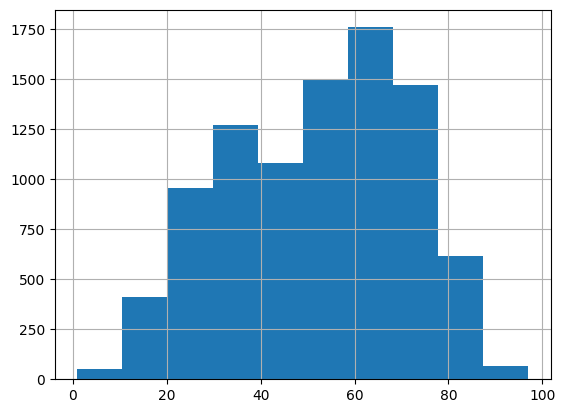

In [ ]:
df[df['age'] < 100]['age'].hist()

In [ ]:
df.loc[df['age'] > 100, 'age'] = np.nan 

Max Age is now: 97.0
TSH skewness before: 12.92
TSH skewness after log: 1.94


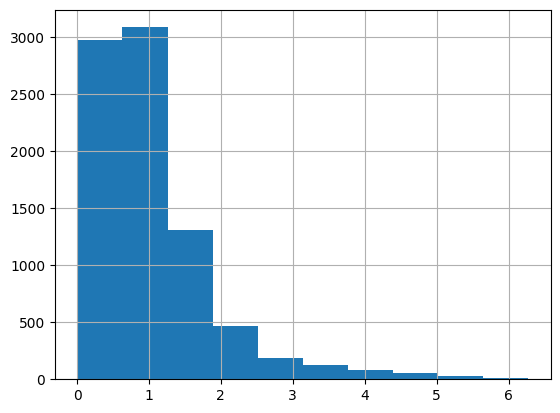

In [ ]:

# We apply a log transformation. 
# We add +1 because log(0) is undefined, and TSH can be 0.
# Formula: TSH_log = log(TSH + 1)
df['TSH_log'] = np.log1p(df['TSH']) #Crea una nueva columna 'TSH_log' con el logaritmo de TSH + 1
print(f"Max Age is now: {df['age'].max()}")
print(f"TSH skewness before: {df['TSH'].skew():.2f}")
print(f"TSH skewness after log: {df['TSH_log'].skew():.2f}")

_ = df['TSH_log'].hist()

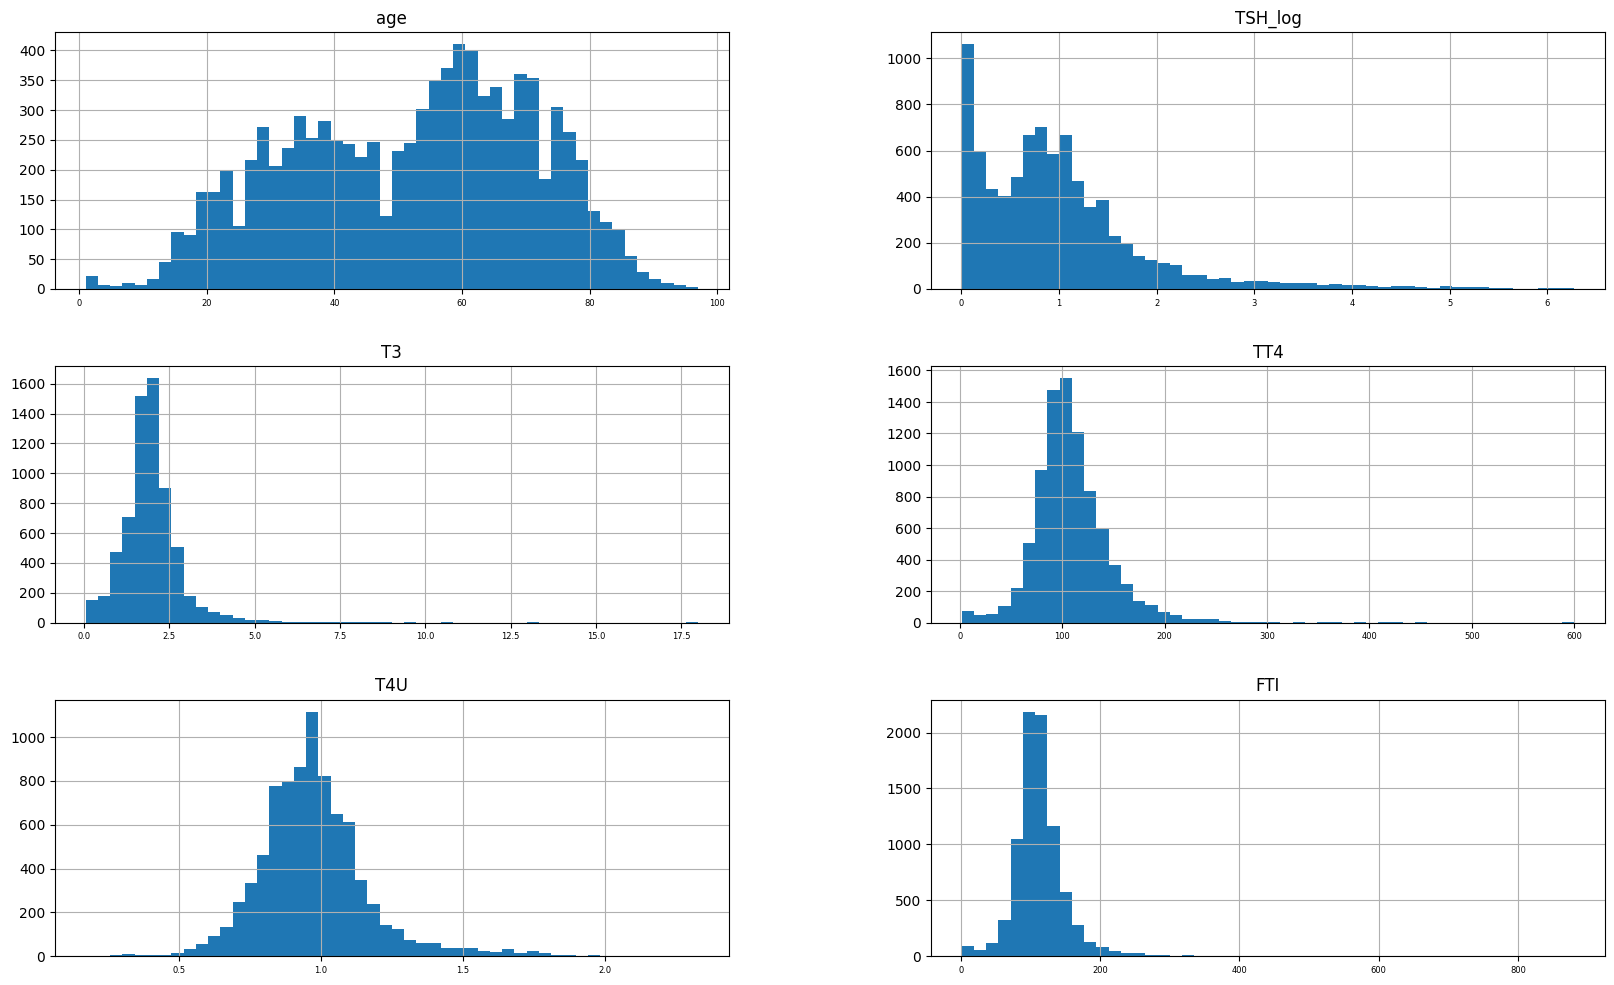

In [ ]:
cleaned_cols = ['age', 'TSH_log', 'T3', 'TT4', 'T4U', 'FTI']
_ = df[cleaned_cols].hist(bins=50, figsize=(20, 12), xlabelsize=6) 

In [ ]:
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percentage': missing_percentages
})

missing_df[missing_df['missing_count'] > 0].sort_values('missing_percentage', ascending=False)

,missing_count,missing_percentage
TBG,8823,96.2
T3,2604,28.4
TSH_log,842,9.2
TSH,842,9.2
T4U,809,8.8
FTI,802,8.7
TT4,442,4.8
sex,307,3.3
age,4,0.0


In [ ]:
# Verify relationship between _measured flags and NaN values
measured_cols = [col for col in df.columns if col.endswith('_measured')]

for col in measured_cols:
    base_col = col.replace('_measured', '')
    if base_col in df.columns:
        measured_true = (df[col] == 't').sum()
        has_value = df[base_col].notna().sum()
        print(f"{base_col}: measured='t' count = {measured_true}, non-null count = {has_value}")

TSH: measured='t' count = 8330, non-null count = 8330
T3: measured='t' count = 6568, non-null count = 6568
TT4: measured='t' count = 8730, non-null count = 8730
T4U: measured='t' count = 8363, non-null count = 8363
FTI: measured='t' count = 8370, non-null count = 8370
TBG: measured='t' count = 349, non-null count = 349


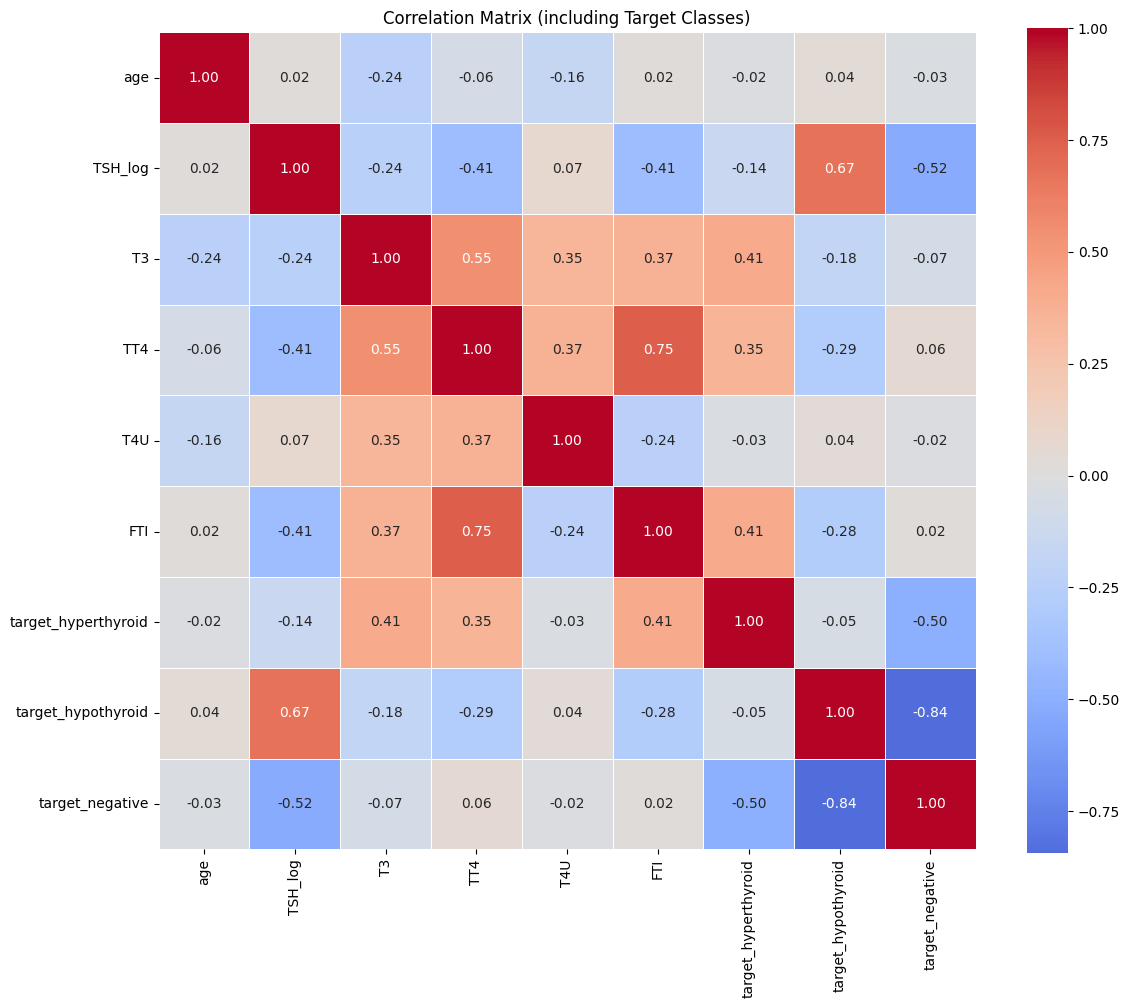

In [ ]:
import seaborn as sns

# Create dummy variables for target classes
target_dummies = pd.get_dummies(df['target'], prefix='target').astype(int)

# Add dummies to features for correlation analysis
df_corr = pd.concat([df[cleaned_cols], target_dummies], axis=1)
correlation_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix (including Target Classes)')
plt.tight_layout()
plt.show()

Empezamos con el dataset


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from src.data_loader import load_thyroid_data_3_classes
X, y = load_thyroid_data_3_classes()
print(f"Datos cargados: X={X.shape}, y={y.shape}")

Datos cargados: X=(9172, 28), y=(9172,)


Antes de transformar los datos vamos a comprobar que tipos de datos son

In [ ]:
print (type(X))
print (type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


Como son datos de pandas primero lo debemos de convertir a Numpy:

In [ ]:
X = X.values
y = y.values
print (type(X))
print (type(y))

<class 'numpy.ndarray'>
<class 'pandas.arrays.StringArray'>


Comprobamos el tipo de datos antes de empezar con los tensores:

In [ ]:
print (type(X))
print (type(y))
print(X.dtype)
print (y.dtype)
print(X.shape)
print(y.shape)

<class 'numpy.ndarray'>
<class 'pandas.arrays.StringArray'>
object
str
(9172, 28)
(9172,)


Convertimos X a dataframe para posteriormente poder aplicar one-hot encoding y transformarlas a columnas numéricas

In [ ]:
import pandas as pd
import numpy as np

X_df = pd.DataFrame(X)

Ahora aplicamos one hot coding a las columnas categóricas y después las forzamos a que sean de tipo numérico:

In [ ]:
X_df = pd.get_dummies(X_df)
X_df = X_df.astype(float)

Convertirmos ahora y a valores numéricos:

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(le.classes_)

['hyperthyroid' 'hypothyroid' 'negative']


Ahora ya podemos convertir a tensores

In [ ]:
import torch

X_tensor = torch.tensor(X_df.to_numpy(), dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

In [ ]:
print ("X_tensor.dtype:", X_tensor.dtype)
print ("y_tensor.dtype:", y_tensor.dtype)

X_tensor.dtype: torch.float32
y_tensor.dtype: torch.int64


Ahora ya tenemos los dos tensores con el tipo de datos que tienen que ser.
Para X_tensor debe ser siempre del tipo float32, 32 porque Pytorch y las GPUs estan optimizadas para trabajar en 32 bits. Tiene que ser de tipo float debido a la siguiente fórmula: y=W⋅X+b, w son los pesos y x los datos de entrada, de manera que al ser una multiplicación debemos de trabajar siempre con números reales.
Y_tensor contiene las etiquetas, es decir, contiene las clases, por eso le asignamos un valor entero a cada una de estas, también utilizamos int porque la función de pérdida que más se usa en clasificación es nn.CrossEntropyLoss() y el resultado esperado por esta es siempre un número entero (LongTensor)

Ahora vamos a proceder a dividir el conjunto de datos en entrenamiento y test, para eso usamos sklearn, de esta forma evitamos el overfitting.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)


Procedemos a definir el modelo de red neuronal:

In [ ]:
import torch.nn as nn

class ThyroidModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ThyroidModel, self).__init__()
        
        # Capa de entrada -> capa oculta
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()

        # Capa oculta -> capa de salida
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Propagación hacia adelante
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        return x

# Parámetros
input_dim = X_train.shape[1]  # Número de características de entrada
hidden_dim = 64  # Número de neuronas en la capa oculta
output_dim = 3  # Número de clases

# Crear el modelo
model = ThyroidModel(input_dim, hidden_dim, output_dim)

Mediante nn.linear (input_dim, hidden_dim)-->Capa completamente conectada que conecta las neuronas de la capa de entrada con las de la capa oculta.
nn.ReLU()-->Función de activación
self.fc2=nn.linear(hidden_dim, output_dim)-->Conecta la capa oculta con la capa de salida (en este caso tiene 3 salidas)

Ahora debemos definir la función de pérdida, en este caso tenemos una clasificación con más de 2 clases, por lo que debemos de utilizar la entropía cruzada "CrossEntropyLoss".
Esta función de pérdida compara las predicciones del modelo con las etiquetas reales y calcula que tan cerca esta el modelo de la verdad.

In [ ]:
criterion = nn.CrossEntropyLoss()

Vamos a definir el optimizador, que es el encargado de actualizar los parámetros del modelo para minimizar la función de pérdida.
Para este caso usaremos Adam que es rápido y eficaz

In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
#lr es la tasa de aprendizaje, indica cuanto de largos son los pasos que vamos dando.

Procedemos al entrenamiento del modelo

COMENTO ESTO SOLO PARA PROBAR



num_epochs = 100  # Número de épocas (iteraciones)

for epoch in range(num_epochs):
    # Enfoque de entrenamiento
    model.train()  # Poner el modelo en modo de entrenamiento
    optimizer.zero_grad()  # Limpiar gradientes de la iteración anterior

    # Paso hacia adelante
    outputs = model(X_train)
    
    # Calcular la pérdida
    loss = criterion(outputs, y_train)

    # Paso hacia atrás (backpropagation)
    loss.backward()

    # Actualización de parámetros
    optimizer.step()

    # Imprimir el progreso
    if (epoch + 1) % 5 == 0:  # Mostrar cada 5 épocas
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


    #La pérdida se calcula en base a cuánto de lejos estas las predicciones de las etiquetas reales

model.train()-->Coloca el modelo en modo de entrenamiento
optimizer.zero_grad()-->Limpia los gradientes de la iteración anterior
loss.backward()-->Calcula los gradientes de los parámetros
optimizer.step()-->Actualiza los parámetros del modelo según los gradientes

Ahora vamos a evaluar nuestro modelo con el conjunto de datos de test_set

COMENTAMOS PARA HACER UNAS PRUEBAS

model.eval()  # Cambia el modelo a modo evaluación

with torch.no_grad():  # Desactiva los gradientes
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)  # Devuelve el índice de la clase con la mayor probabilidad
    accuracy = (predicted == y_test).sum().item() / y_test.size(0)

print(f'Accuracy on test data: {accuracy * 100:.2f}%')

Epoch [5/100], Loss Train: 1.0324, Loss Test: 1.0002
Epoch [10/100], Loss Train: 0.8720, Loss Test: 0.8286
Epoch [15/100], Loss Train: 0.6956, Loss Test: 0.6463
Epoch [20/100], Loss Train: 0.5397, Loss Test: 0.4898
Epoch [25/100], Loss Train: 0.4331, Loss Test: 0.3854
Epoch [30/100], Loss Train: 0.3819, Loss Test: 0.3350
Epoch [35/100], Loss Train: 0.3659, Loss Test: 0.3175
Epoch [40/100], Loss Train: 0.3601, Loss Test: 0.3105
Epoch [45/100], Loss Train: 0.3522, Loss Test: 0.3039
Epoch [50/100], Loss Train: 0.3412, Loss Test: 0.2967
Epoch [55/100], Loss Train: 0.3293, Loss Test: 0.2903
Epoch [60/100], Loss Train: 0.3189, Loss Test: 0.2854
Epoch [65/100], Loss Train: 0.3100, Loss Test: 0.2811
Epoch [70/100], Loss Train: 0.3011, Loss Test: 0.2758
Epoch [75/100], Loss Train: 0.2916, Loss Test: 0.2691
Epoch [80/100], Loss Train: 0.2817, Loss Test: 0.2620
Epoch [85/100], Loss Train: 0.2717, Loss Test: 0.2551
Epoch [90/100], Loss Train: 0.2616, Loss Test: 0.2483
Epoch [95/100], Loss Train: 0

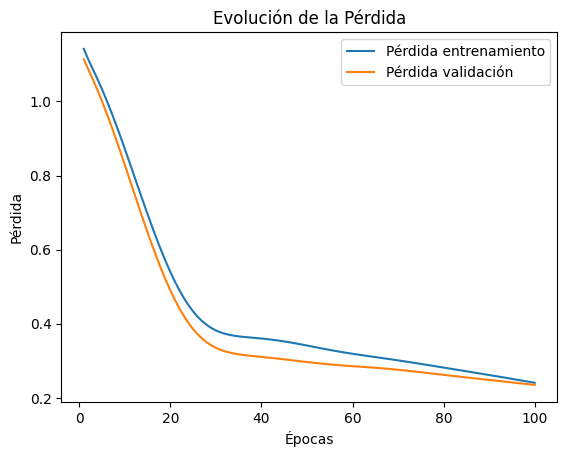

In [ ]:
train_loss = []  # Lista para almacenar la pérdida de entrenamiento
val_loss = []    # Lista para almacenar la pérdida de validación

num_epochs = 100  # Definir el número de épocas

for epoch in range(num_epochs):
    model.train()  # Pone el modelo en modo de entrenamiento
    optimizer.zero_grad()  # Limpia los gradientes del paso anterior

    # Paso hacia adelante (train)
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    loss.backward()  # Cálculo de los gradientes
    optimizer.step()  # Actualización de los parámetros

    # Almacena la pérdida de entrenamiento
    train_loss.append(loss.item())

    # Evaluación en datos de prueba
    model.eval()  # Pone el modelo en modo de evaluación
    with torch.no_grad():  # Desactiva el cálculo de gradientes para validación
        val_outputs = model(X_test)
        val_loss_val = criterion(val_outputs, y_test)  # Pérdida en validación
        val_loss.append(val_loss_val.item())  # Almacena la pérdida de validación

    # Imprimir progreso cada 5 épocas
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss Train: {loss.item():.4f}, Loss Test: {val_loss_val.item():.4f}')

# Al final, podrás graficar las pérdidas:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs+1), train_loss, label="Pérdida entrenamiento")
plt.plot(range(1, num_epochs+1), val_loss, label="Pérdida validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de la Pérdida")
plt.legend()
plt.show()

model.eval()--> Ponemos el modelo en modo evaluación
torch.no_grad()-->Desactivamos los gradientes ya que no son necesarios en la evaluación

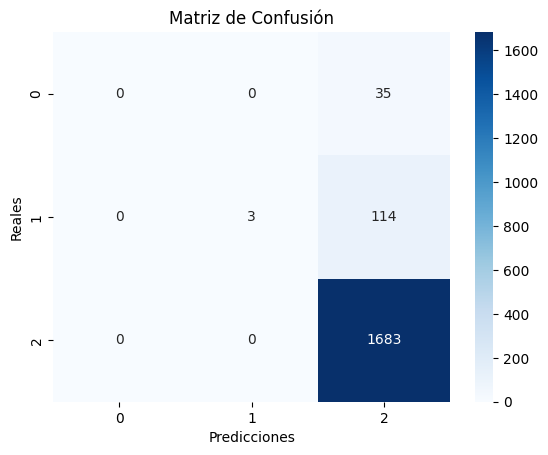

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Asegúrate de que 'le' (LabelEncoder) esté definido
# Si no lo has hecho antes, define 'le' y ajustalo con y_train
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)  # Ajusta le con las etiquetas de entrenamiento

# Realizar predicciones en el conjunto de prueba
model.eval()  # Cambiar a modo de evaluación
with torch.no_grad():  # Desactiva la computación de gradientes
    y_pred = model(X_test)
    _, y_pred = torch.max(y_pred, 1)  # Obtener las clases predichas con mayor probabilidad

# Convertir las predicciones y etiquetas verdaderas a NumPy para calcular la matriz de confusión
y_test = y_test.numpy()  # Asegúrate de que y_test esté en formato NumPy
y_pred = y_pred.numpy()  # Convertir las predicciones a NumPy

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de Confusión")
plt.xlabel("Predicciones")
plt.ylabel("Reales")
plt.show()

In [ ]:
torch.save(model.state_dict(), 'thyroid_model.pth') #Guardamos el modelo entrenado